In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Análisis exploratorio de datos


In [16]:
df_diabetes = pd.read_csv("./diabetes.csv")
df_diabetes.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [17]:
# Eliminamos la columna "Unnamed: 0", que es solo un índice residual del csv y no aporta información
df_diabetes = df_diabetes.drop(columns=["Unnamed: 0"])
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [18]:
print("Número de instancias:", df_diabetes.shape[0])
print("Número total de columnas:", df_diabetes.shape[1])
print("Número de atributos predictores:", df_diabetes.shape[1] - 1)

Número de instancias: 768
Número total de columnas: 9
Número de atributos predictores: 8


- ¿Cuál es la variable objetivo (target) y qué representa cada uno de sus valores?

--> La *variable objetivo* (target) es la variable **"Outcome"**, y sus variables 1 y 0 representan si la paciente presenta o no diabetes respectivamente 
- ¿Qué representa cada **fila** del dataset?

--> Cada **fila** del dataset representa a una paciente distinta
- ¿Qué representa cada **columna**?

--> Cada una de las **columnas** del dataset representa una variable clínica distinta, estas pueden ser: número de embarazos, nivel de glucosa en sangre, presión arterial, nivel de insulina, edad, entre otras.

- ¿Qué tipo de problema de aprendizaje automático es este: **clasificación** o **regresión**? Justificá por qué.

--> Este dataset representa un **problema de clasificación**. Esto se debe a que la variable objetivo, "Outcome", no es una medida continua sino una etiqueta categórica que solo puede tomar dos valores posibles: 0 (paciente sin diabetes) o 1 (paciente con diabetes). El objetivo del modelo no es predecir una cantidad (como ocurriría en un problema de regresión, por ej. al estimar el precio de una vivienda), sino determinar a cuál de dos clases mutuamente excluyentes pertenece cada paciente en función de sus mediciones clínicas (glucosa, presión arterial, BMI, edad, etc.). Además, aunque Outcome esté codificado numéricamente (0 y 1), estos números no representan una escala ordinal ni una cantidad, ya que no existe un valor intermedio entre tener y no tener diabetes, lo cual confirma que es categórica y, por lo tanto, que se trata de un problema de clasificación

## 2. Exploración inicial de los datos

In [19]:
df_diabetes.info() #Para conocer los atributos existentes y el número de instancias pertenecientes a cada atributo

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             767 non-null    float64
 3   SkinThickness             756 non-null    float64
 4   Insulin                   763 non-null    float64
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.1 KB


- ¿Qué tipos de datos aparecen en el dataset (enteros, flotantes, etc.)? ¿Hay columnas categóricas?

-->

In [20]:
df_diabetes.isnull().sum() #Se cuentan todos los NaN por columna, para ver si hay valores faltantes en el dataset

Pregnancies                  0
Glucose                      0
BloodPressure                1
SkinThickness               12
Insulin                      5
BMI                          1
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

- ¿Existen valores faltantes (NaN) en el dataset? 

-->

In [21]:
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,767.000000,756.000000,763.000000,767.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.195567,20.862434,80.322412,32.034289,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.206609,15.865314,115.439459,7.804050,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,36.000000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,128.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


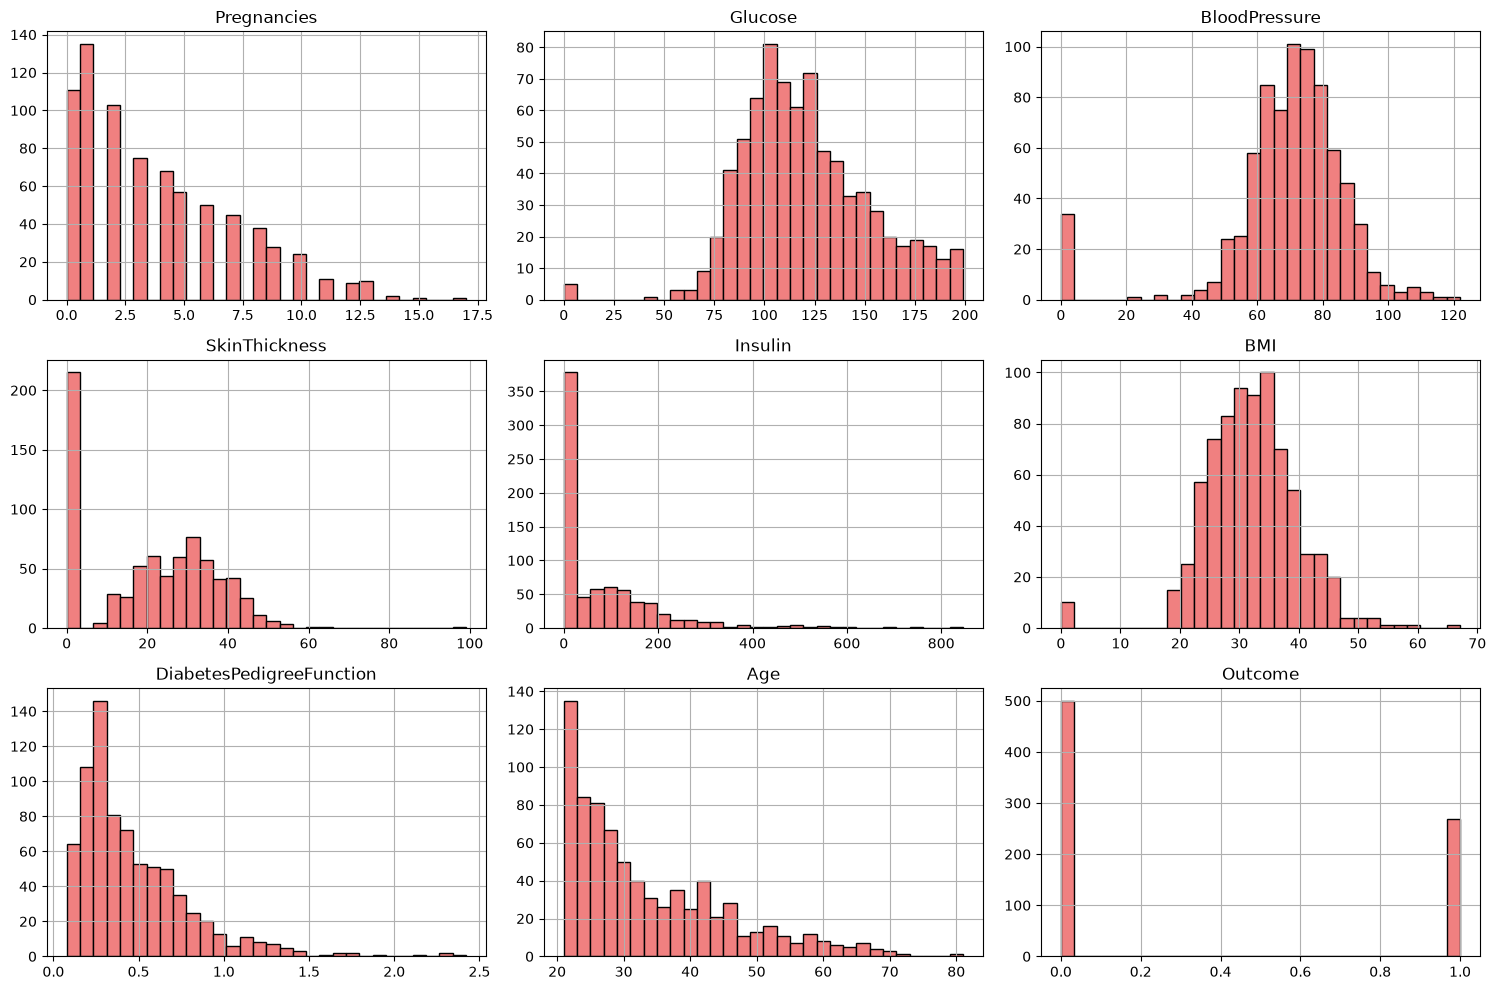

In [22]:
df_diabetes.hist(bins=30, figsize=(15, 10), edgecolor="k", color= "lightcoral") #Genera histogramas para cada atributo del dataset
plt.tight_layout()
plt.show()

- ¿Existen variables con **distribuciones sesgadas**? ¿Cuáles y hacia qué lado?

-->
- ¿Existen variables con **escalas muy diferentes** entre sí? 

-->

## 3. División del dataset en entrenamiento y prueba

Se deben separar los datos en dos partes debido a que, de esta manera es posible conocer si el modelo realmente aprendió a partir de los datos. Si entrenáramos y evaluáramos con los mismos datos, no sabríamos si el modelo realmente aprendió el patrón clínico de la diabetes o si simplemente "memorizó" esos casos puntuales.

In [23]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    df_diabetes, test_size=0.2, stratify=df_diabetes["Outcome"], random_state=42
)

print("Train:", train_set.shape)
print("Test:", test_set.shape)
print()
print("Proporción de Outcome en train:")
print(train_set["Outcome"].value_counts(normalize=True))
print()
print("Proporción de Outcome en test:")
print(test_set["Outcome"].value_counts(normalize=True))

Train: (614, 9)
Test: (154, 9)

Proporción de Outcome en train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Proporción de Outcome en test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


Para dividir los datos se utilizó **train_test_split** con un test_size de 0.2, reservando el **20%** de las pacientes para el conjunto de **prueba** y el **80%** para **entrenamiento**. Como la variable "Outcome" presenta un desbalance de clases (65% sin diabetes, 35% con diabetes), se aplicó **muestreo estratificado** (stratify=Outcome) para garantizar que ambos subconjuntos (entrenamiento y prueba) mantuvieran una proporción similar de pacientes con y sin diabetes, evitando así que el azar generara una división poco representativa. Se fijó además random_state=42 para asegurar la reproducibilidad del split

A partir de esta sección solo **vamos a trabajar con train_set**, los datos en test_set se van a guardar y soló serán utilizados cuando se evalue el modelo

In [24]:
# Hacemos una copia de trabajo del conjunto de entrenamiento
diabetes_train = train_set.copy()

 ## 4. Análisis de posibles problemas en los datos